In [2]:
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import scipy.signal as signal

In [3]:
# define path to data and sampling frequency
# adjust the path depending on if you run this script locally or on Kaggle
# DATA_PATH = '/kaggle/input/competitions/ppg-br-exercise-1/mhealth26_ex1.npy'  # for Kaggle
DATA_PATH = './mhealth26_ex1.npy'  # when running locally
FS = 100

In [4]:
# load dictionary from .npy
data = np.load(DATA_PATH, allow_pickle=True).item()

# extract arrays
X_train = data['train_ppg']      
y_train = data['train_labels']   
X_test  = data['test_ppg']       

In [5]:
# example function to plot any signal with time on the x-axis
def plot_signal(signal, title, ylabel, sampling_rate=100):
    x = np.linspace(0, len(signal) / sampling_rate, len(signal))
    t = pd.to_datetime(x, unit='s')

    fig, ax = plt.subplots()
    ax.plot(t, signal)
    ax.set_title(title)
    ax.set_xlabel('Time [min:sec]')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%M:%S'))
    plt.show()

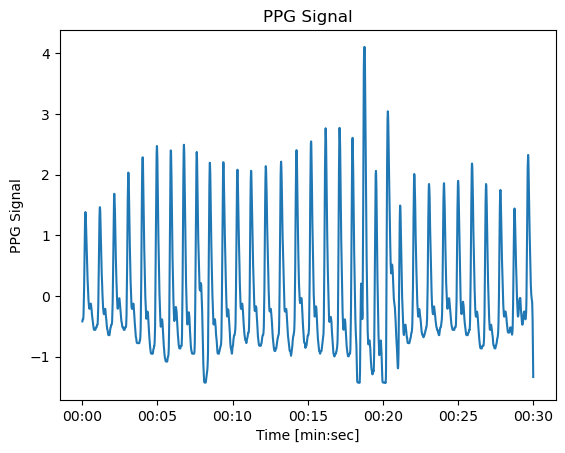

In [33]:
# plot the first 30 seconds of the unfiltered ppg signal of the first window
plot_signal(X_test[0][0:30*FS], 'PPG Signal', 'PPG Signal')

# Pre-Training

## PREPROCESSING

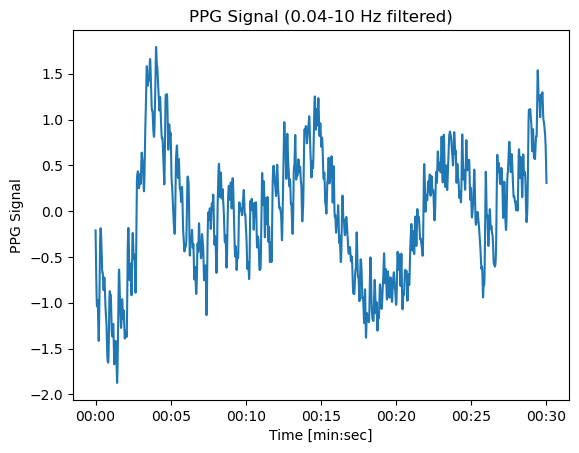

In [29]:
# PREPROCESSING
# Remove baseline drift (<0.03-0.05 Hz) and high-frequency noise (>20 Hz).

def highpass_filter(ppg_window, fs=100, cutoff_hz=0.04, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_hz / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='highpass')
    return signal.filtfilt(b, a, ppg_window)

def lowpass_filter(ppg_window, fs=100, cutoff_hz=10.0, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_hz / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='lowpass')
    return signal.filtfilt(b, a, ppg_window)

def preprocess_window(ppg_window, fs=100, hp_cutoff_hz=0.04, lp_cutoff_hz=10.0):
    x = highpass_filter(ppg_window, fs=fs, cutoff_hz=hp_cutoff_hz, order=2)
    x = lowpass_filter(x, fs=fs, cutoff_hz=lp_cutoff_hz, order=4)
    return x

# Apply per 120-second window for train/test sets
X_train_filt = np.array([preprocess_window(w, fs=FS, hp_cutoff_hz=0.04, lp_cutoff_hz=10.0) for w in X_train])
X_test_filt = np.array([preprocess_window(w, fs=FS, hp_cutoff_hz=0.04, lp_cutoff_hz=10.0) for w in X_test])

# Optional quick check: plot first 30s of filtered test window
plot_signal(X_test_filt[19][0:30*FS], 'PPG Signal (0.04-10 Hz filtered)', 'PPG Signal')


## EXTRACT RESPIRATORY SIGNALS

In [ ]:
# RESAMPLE RESPIRATORY SIGNALS
# BW, AM, FM are beat-based (irregular sampling).
# Resample each to a uniform 4 Hz grid using cubic spline interpolation.

from scipy.interpolate import CubicSpline

RESP_FS = 4  # target respiratory-signal sample rate (Hz)

def resample_resp(ppg_window, extract_fn, fs=100, resp_fs=RESP_FS):
    """Extract a beat-level surrogate then resample it to resp_fs Hz."""
    peaks, _ = signal.find_peaks(ppg_window, distance=int(0.4 * fs), prominence=0)
    troughs, _ = signal.find_peaks(-ppg_window, distance=int(0.4 * fs))

    beat_times = []   # in seconds
    beat_values = []

    if extract_fn == 'bw':
        for pk in peaks:
            preceding = troughs[troughs < pk]
            if len(preceding) == 0:
                continue
            tr = preceding[-1]
            beat_times.append(pk / fs)
            beat_values.append((ppg_window[pk] + ppg_window[tr]) / 2.0)

    elif extract_fn == 'am':
        for pk in peaks:
            preceding = troughs[troughs < pk]
            if len(preceding) == 0:
                continue
            tr = preceding[-1]
            beat_times.append(pk / fs)
            beat_values.append(ppg_window[pk] - ppg_window[tr])

    elif extract_fn == 'fm':
        if len(peaks) < 3:
            duration = len(ppg_window) / fs
            n_out = int(duration * resp_fs)
            return np.zeros(n_out), np.linspace(0, duration, n_out, endpoint=False)
        ibi = np.diff(peaks).astype(float) / fs
        beat_times = (peaks[1:] / fs).tolist()
        beat_values = ibi.tolist()

    beat_times = np.array(beat_times)
    beat_values = np.array(beat_values)

    if len(beat_times) < 3:
        duration = len(ppg_window) / fs
        n_out = int(duration * resp_fs)
        return np.zeros(n_out), np.linspace(0, duration, n_out, endpoint=False)

    # Uniform time grid at resp_fs Hz spanning the beat-time range
    duration = len(ppg_window) / fs
    t_uniform = np.linspace(0, duration, int(duration * resp_fs), endpoint=False)

    # Cubic spline interpolation (clamp to beat-time range to avoid extrapolation artefacts)
    cs = CubicSpline(beat_times, beat_values, extrapolate=True)
    resampled = cs(t_uniform)

    return resampled, t_uniform

# Demo: resample all three surrogates for one window
demo_idx = 0
ppg_demo = X_test_filt[demo_idx]

bw_resp, t_resp = resample_resp(ppg_demo, 'bw', fs=FS)
am_resp, _      = resample_resp(ppg_demo, 'am', fs=FS)
fm_resp, _      = resample_resp(ppg_demo, 'fm', fs=FS)

plot_signal(bw_resp, f'BW resampled @ {RESP_FS} Hz (window {demo_idx})', 'BW', sampling_rate=RESP_FS)
plot_signal(am_resp, f'AM resampled @ {RESP_FS} Hz (window {demo_idx})', 'AM', sampling_rate=RESP_FS)
plot_signal(fm_resp, f'FM resampled @ {RESP_FS} Hz (window {demo_idx})', 'IBI (s)', sampling_rate=RESP_FS)

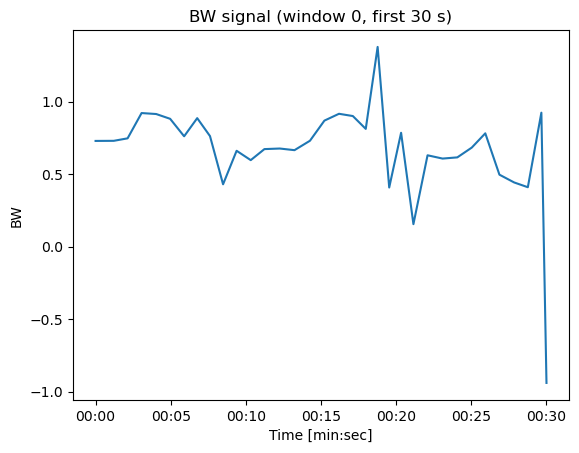

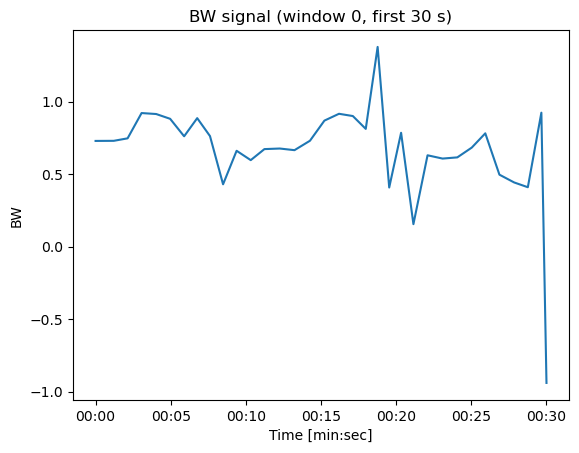

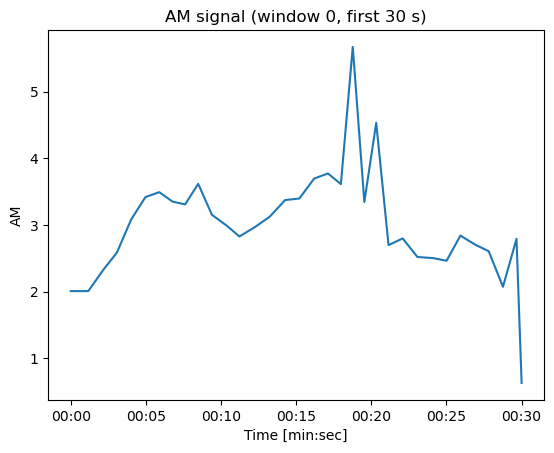

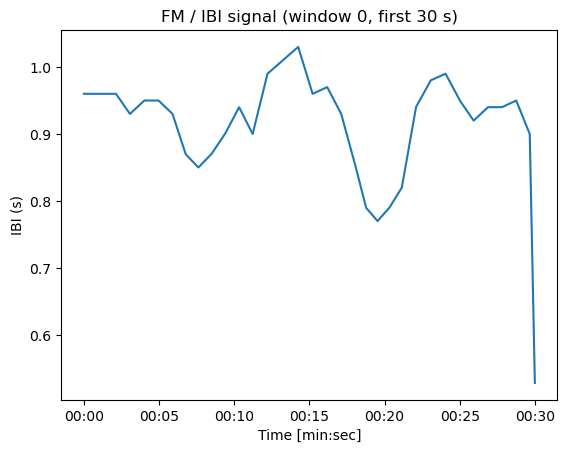

In [36]:
# BW – Baseline Wander
# For each PPG pulse: BW[n] = (peak_amp[n] + preceding_trough_amp[n]) / 2
# Returns sample-level BW signal (linearly interpolated between pulse instants).

def extract_bw(ppg_window, fs=100):
    # Detect systolic peaks (positive prominences)
    peaks, _ = signal.find_peaks(ppg_window, distance=int(0.4 * fs), prominence=0)
    # Detect troughs (= peaks of inverted signal)
    troughs, _ = signal.find_peaks(-ppg_window, distance=int(0.4 * fs))

    if len(peaks) < 2 or len(troughs) < 1:
        return np.zeros_like(ppg_window)

    bw_times = []
    bw_values = []

    for pk in peaks:
        # Find the closest preceding trough
        preceding = troughs[troughs < pk]
        if len(preceding) == 0:
            continue
        tr = preceding[-1]
        bw_times.append(pk)
        bw_values.append((ppg_window[pk] + ppg_window[tr]) / 2.0)

    if len(bw_times) < 2:
        return np.zeros_like(ppg_window)

    bw_times = np.array(bw_times)
    bw_values = np.array(bw_values)

    # Interpolate to full sample rate
    bw_signal = np.interp(np.arange(len(ppg_window)), bw_times, bw_values)
    return bw_signal

# AM – Amplitude Modulation
# For each PPG pulse: AM[n] = peak_amp[n] - preceding_trough_amp[n]
# Returns sample-level AM signal (linearly interpolated between pulse instants).

def extract_am(ppg_window, fs=100):
    peaks, _ = signal.find_peaks(ppg_window, distance=int(0.4 * fs), prominence=0)
    troughs, _ = signal.find_peaks(-ppg_window, distance=int(0.4 * fs))

    if len(peaks) < 2 or len(troughs) < 1:
        return np.zeros_like(ppg_window)

    am_times = []
    am_values = []

    for pk in peaks:
        preceding = troughs[troughs < pk]
        if len(preceding) == 0:
            continue
        tr = preceding[-1]
        am_times.append(pk)
        am_values.append(ppg_window[pk] - ppg_window[tr])

    if len(am_times) < 2:
        return np.zeros_like(ppg_window)

    am_times = np.array(am_times)
    am_values = np.array(am_values)

    am_signal = np.interp(np.arange(len(ppg_window)), am_times, am_values)
    return am_signal

# Quick demos on one filtered test window
demo_idx = 0
bw_demo = extract_bw(X_test_filt[demo_idx], fs=FS)
plot_signal(bw_demo[0:30*FS], f'BW signal (window {demo_idx}, first 30 s)', 'BW')

# FM – Frequency Modulation (inter-beat interval series)
# IBI[n] = t_peak[n] - t_peak[n-1]  (in seconds)
# Captures respiratory sinus arrhythmia.
# Returns sample-level FM signal (linearly interpolated between pulse instants).

def extract_fm(ppg_window, fs=100):
    peaks, _ = signal.find_peaks(ppg_window, distance=int(0.4 * fs), prominence=0)

    if len(peaks) < 3:
        return np.zeros_like(ppg_window)

    ibi_times = peaks[1:]                                   # time index of each IBI
    ibi_values = np.diff(peaks).astype(float) / fs          # IBI in seconds

    fm_signal = np.interp(np.arange(len(ppg_window)), ibi_times, ibi_values)
    return fm_signal

# Quick demos on one filtered test window
demo_idx = 0

bw_demo = extract_bw(X_test_filt[demo_idx], fs=FS)
plot_signal(bw_demo[0:30*FS], f'BW signal (window {demo_idx}, first 30 s)', 'BW')

am_demo = extract_am(X_test_filt[demo_idx], fs=FS)
plot_signal(am_demo[0:30*FS], f'AM signal (window {demo_idx}, first 30 s)', 'AM')

fm_demo = extract_fm(X_test_filt[demo_idx], fs=FS)
plot_signal(fm_demo[0:30*FS], f'FM / IBI signal (window {demo_idx}, first 30 s)', 'IBI (s)')

In [ ]:
# Resample Respiratory Signals

# Training

In [ ]:
# function to predict BR for a single 120-second window
def predict_br(ppg):
    
    # ToDo: implement your BR prediction algorithm here
    # this is a dummy example that predicts random values
    pred = [np.random.randint(8, 40)]

    return pred

In [ ]:
# function to print the mean absolute error between your predicted BR and the BR labels
# with this function, you can evaluate the resulting score that you would obtain on the test set
# with your predicted BR values
def print_score(pred_br, label_br):
    err = np.abs(np.asarray(pred_br) - np.asarray(label_br))
    print("Mean absolute error: {:4.3f}".format(np.mean(err)))

In [ ]:
# create the submission file called "submission.csv"
# download the file and submit it to the kaggle competition to obtain a score on the leaderboard
idxs = []
preds = []

# loop through all test windows
# important: loop through the windows as below, add the predictions in the same order and keep the naming of window{i}_{j}
# we will only evaluate your predictions for the test set
for i, ppg in enumerate(X_test):
    # index needed for kaggle submission file
    idxs.extend([i])
    # your predictions based on the above function
    preds.extend(predict_br(ppg))

# on the right side in tab "Output", you should now see a file called "submission.csv" after pressing the refresh button
# download the file and submit it to this competition to obtain a score on the leaderboard
df = pd.DataFrame({'Id': idxs, 'Predicted': preds})
# df.to_csv('/kaggle/working/submission.csv', index=False)  # for Kaggle
df.to_csv('./submission.csv', index=False)  # when running locally

In [ ]:
# example on how to use the print_score function with randomly generated BR values as the predictions and labels
pred_br_random = list(np.random.randint(8, 40, len(preds)))
label_br_random = list(np.random.randint(8, 40, len(preds)))
print_score(pred_br_random, label_br_random)